In [ ]:
 from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


connects google drive to colab, so that it can access any file in the drive

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Lung_Abnormality_dataset/Chest X-Ray Image"

print("Folders inside dataset:\n")
print(os.listdir(dataset_path))

Folders inside dataset:

['Viral Pneumonia', 'Normal', 'Lung_Opacity', 'COVID']


importing pythons os module to work with folders and files, stores the path of the data set folder in google drive. lists and prints all items inside the dataset

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Lung_Abnormality_dataset/Chest X-Ray Image"

class_counts = {}

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        class_counts[folder] = len(os.listdir(folder_path))

print("Image count per class:\n")

for k,v in class_counts.items():
    print(k, ":", v)

Image count per class:

Viral Pneumonia : 1050
Normal : 1000
Lung_Opacity : 1200
COVID : 1100


counts how many images are in each class, It helps check class imbalance.

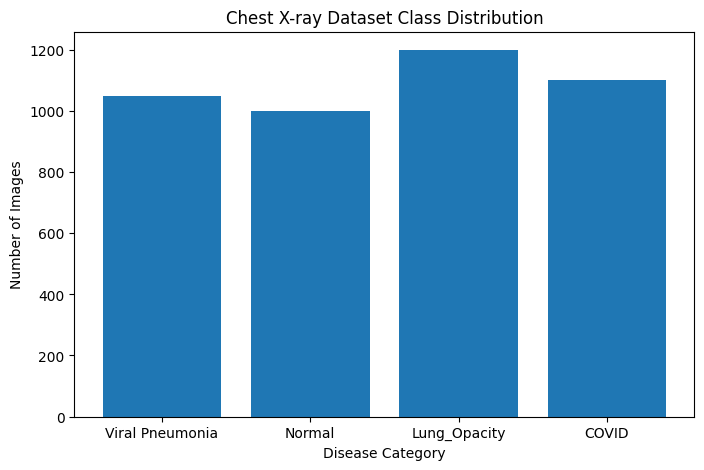

In [ ]:
import matplotlib.pyplot as plt

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(8,5))
plt.bar(classes, counts)

plt.title("Chest X-ray Dataset Class Distribution")
plt.xlabel("Disease Category")
plt.ylabel("Number of Images")

plt.show()

Creates a bar chart showing dataset distribution.This helps to visualizes dataset balance.

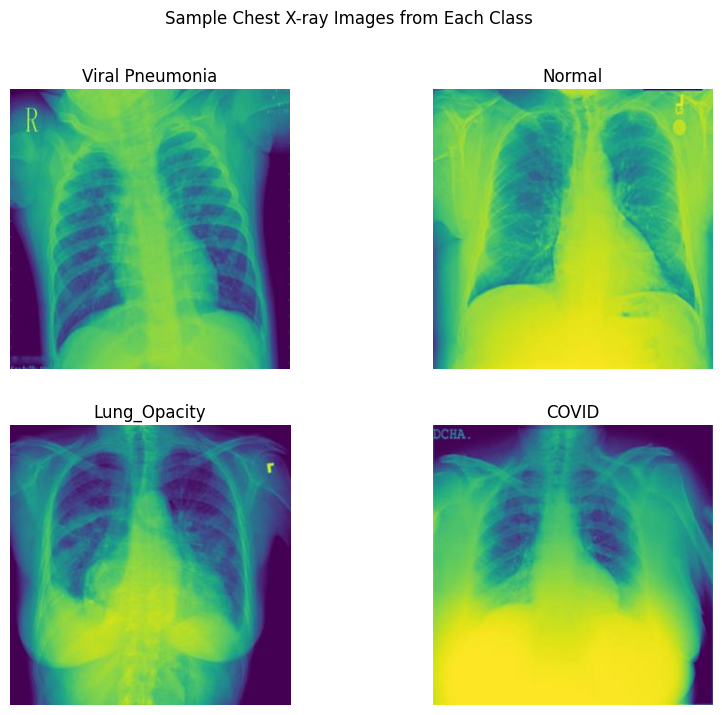

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt
import os

dataset_path = "/content/drive/MyDrive/Lung_Abnormality_dataset/Chest X-Ray Image"

# keep only actual folders (ignore .DS_Store)
classes = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]

plt.figure(figsize=(10,8))

for i, cls in enumerate(classes):

    folder = os.path.join(dataset_path, cls)

    image_name = random.choice(os.listdir(folder))

    image_path = os.path.join(folder, image_name)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Sample Chest X-ray Images from Each Class")

plt.show()

In this cell we pick a random X-ray images from each class for dataset inspection

## Pixel Intensity Distribution

In [ ]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/Lung_Abnormality_dataset/Chest X-Ray Image"

pixel_values = []
sample_images = []

# collect image paths
for cls in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, cls)

    if not os.path.isdir(class_folder):
        continue

    for img_name in os.listdir(class_folder):
        sample_images.append(os.path.join(class_folder, img_name))

# randomly sample 200 images
sample_images = random.sample(sample_images, 200)

for img_path in sample_images:

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        pixel_values.extend(img.flatten())

pixel_values = np.array(pixel_values)

print("Pixels analysed:", len(pixel_values))

Pixels analysed: 17880200


Created two lists to collect pixel intensities and image file paths.

Loop over all the items in dataset. Randomly choose 200 images from all available ones.

Read as single channel greyscale image, if succed flatten 2D image to 1D array and all pixel vaules to list.

Convert to numpy array. Print total number of pixels collected.

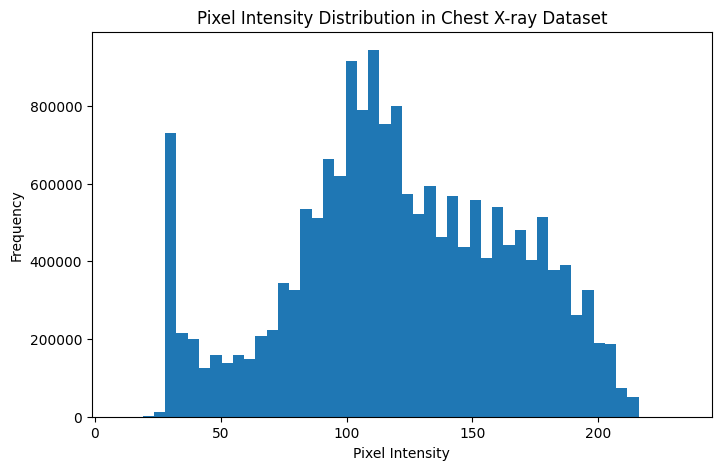

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(pixel_values, bins=50)

plt.title("Pixel Intensity Distribution in Chest X-ray Dataset")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

Create a Histogram of Pixel_values and Displayed to show how bright the dataset images are in general

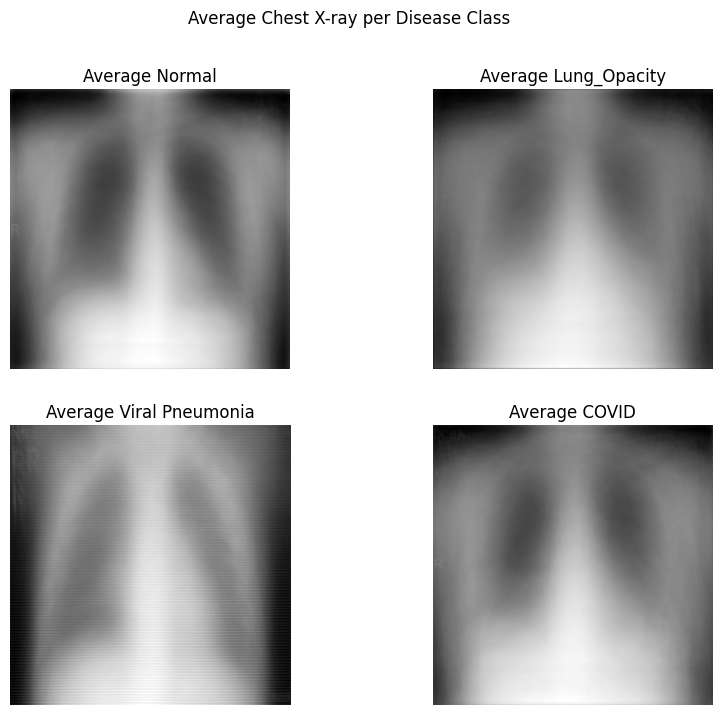

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/Lung_Abnormality_dataset/Chest X-Ray Image"

# explicitly define the four classes
classes = ["Normal", "Lung_Opacity", "Viral Pneumonia", "COVID"]

plt.figure(figsize=(10,8))

for i, cls in enumerate(classes):

    class_folder = os.path.join(dataset_path, cls)

    images = []

    img_list = os.listdir(class_folder)[:150]

    for img_name in img_list:

        img_path = os.path.join(class_folder, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            images.append(img)

    avg_image = np.mean(images, axis=0)

    plt.subplot(2,2,i+1)
    plt.imshow(avg_image, cmap="gray")
    plt.title(f"Average {cls}")
    plt.axis("off")

plt.suptitle("Average Chest X-ray per Disease Class")

plt.show()

GIVES YOU ROUGH PROTOTYPE X-RAY FOR EACH CLASS.  
Defined the Class Order, for each class build path inti with images list.

Use the first 150 images to limit the memory, read each one as grayscale and append it to images list.

Pixel wise avg, the result is avg image of that class. then show the average image in 2*2 subplot grid.

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Lung_Abnormality_dataset/Chest X-Ray Image"

for item in os.listdir(dataset_path):
    if item == ".DS_Store":
        os.remove(os.path.join(dataset_path, item))
        print(".DS_Store removed")

Removes .DS_Store from the dataset root if it exists. This avoids errors when reading folders.

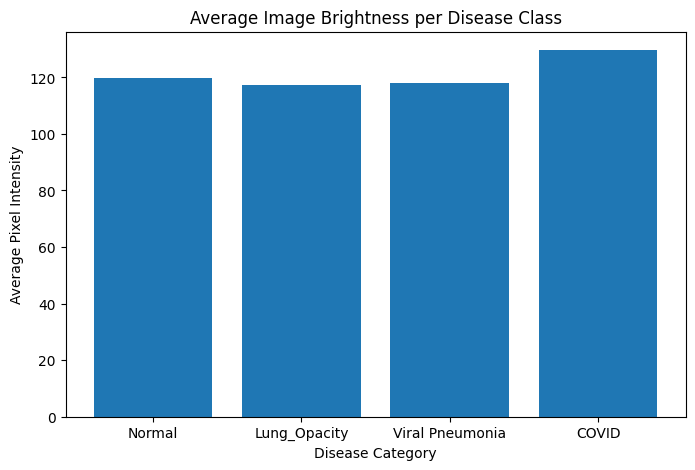

In [ ]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

dataset_path = "/content/drive/MyDrive/Lung_Abnormality_dataset/Chest X-Ray Image"

classes = ["Normal", "Lung_Opacity", "Viral Pneumonia", "COVID"]

brightness = []

for cls in classes:

    class_folder = os.path.join(dataset_path, cls)

    values = []

    img_list = os.listdir(class_folder)[:150]

    for img_name in img_list:

        img_path = os.path.join(class_folder, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is not None:
            values.append(np.mean(img))

    brightness.append(np.mean(values))

plt.figure(figsize=(8,5))

plt.bar(classes, brightness)

plt.title("Average Image Brightness per Disease Class")
plt.xlabel("Disease Category")
plt.ylabel("Average Pixel Intensity")

plt.show()

This cell calculates average brightness of images.

Check whether images have consistent lighting.

Medical models can perform poorly if brightness varies too much.

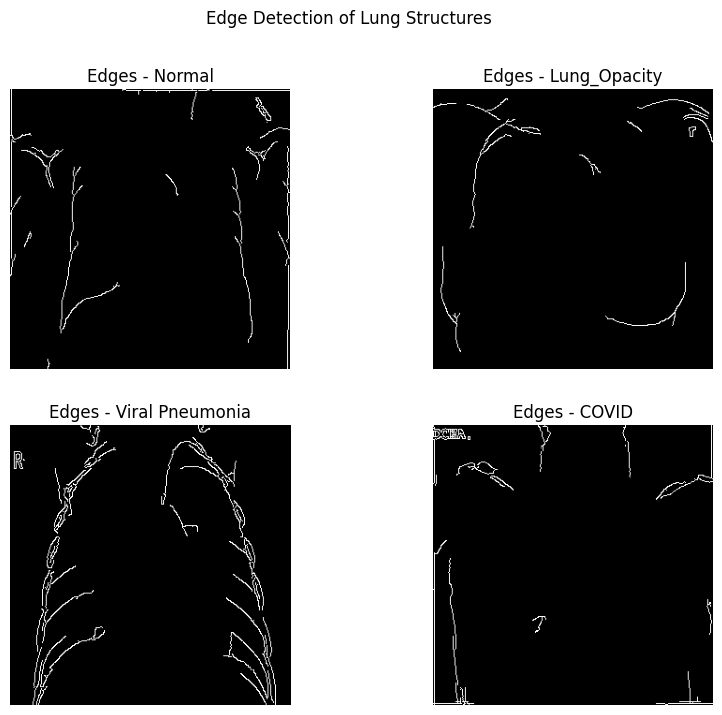

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os
import random

dataset_path = "/content/drive/MyDrive/Lung_Abnormality_dataset/Chest X-Ray Image"

classes = ["Normal", "Lung_Opacity", "Viral Pneumonia", "COVID"]

plt.figure(figsize=(10,8))

for i, cls in enumerate(classes):

    class_folder = os.path.join(dataset_path, cls)

    img_name = random.choice(os.listdir(class_folder))
    img_path = os.path.join(class_folder, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    edges = cv2.Canny(img, 50, 150)

    plt.subplot(2,2,i+1)
    plt.imshow(edges, cmap="gray")
    plt.title(f"Edges - {cls}")
    plt.axis("off")

plt.suptitle("Edge Detection of Lung Structures")

plt.show()

Picks one random grayscale image per class.

Applies Cannyedge detection; thresholds 50 and 150.

Plot edge maps as 2*2 grid.

Highlights lung boundries and structures.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

dataset_path = "/content/drive/MyDrive/Lung_Abnormality_dataset/Chest X-Ray Image"

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(dataset_path, transform=transform)

print("Total images:", len(dataset))
print("Classes:", dataset.classes)

Total images: 4350
Classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


Import datasets, transforms from torchvision. and DataLoader, random_split from torch.utils.data

Pipeline of image transformations:
1.Resize images to 224*224 pixels
2.Convert grayscales to 3 channel grayscale coz models expect 3 channels
3.Convert img to PyTorch tensor

Automatically reads images from subfolders, each subfolder name is class label. Applies transform to each image when loaded.

Print total number of images and Class names as detected by ImageFolder.

In [ ]:
from torch.utils.data import random_split, DataLoader

dataset_size = len(dataset)

train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 3045
Validation size: 652
Test size: 653


Re-import random_split and DataLoader.

Print total number of samples

Compute split sizes into 70% train, 15% val, Rest test

Random_split randomly splits dataset into 3 subsets with those sizes.

Print the actual sizes for each subset

In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

DataLoader helps feed data into the model in batches, 32 images per iteration.

train_loader shuffles the training data each epoch and val_loader/test_loader evaluate in fixed order.

Because loading all images at once is too heavy for memory

# Baseline CNN (ResNet50 — frozen)

In [ ]:


import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load pretrained ResNet50
model1 = models.resnet50(pretrained=True)

# freeze all convolution layers (feature extractor stays fixed)
for param in model1.parameters():
    param.requires_grad = False

# replace final classification layer for 4 classes
num_features = model1.fc.in_features
model1.fc = nn.Linear(num_features, 4)

model1 = model1.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.fc.parameters(), lr=1e-4)

epochs = 5

for epoch in range(epochs):

    model1.train()
    running_loss = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model1(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/5 - Loss: 1.2285
Epoch 2/5 - Loss: 0.9994
Epoch 3/5 - Loss: 0.8752
Epoch 4/5 - Loss: 0.7962
Epoch 5/5 - Loss: 0.7469


Import Core PyTorch library, neural network layers and optimizers

Imported models for pre built architectures like ResNet

Download ResNet-50 model pretrained, this gives you deep CNN that already knows generic visual features(edges, textures, shapes)

All layers are frozon and acts like feature extractor.

ResNet50 now acts as a fixed feature extractor.

model1.fc is original ImageNet with 1000 features, now we replace it with new linear layer to 4 classes

sends the whole network to gpu or cpu

crossentropyloss measures how wrong is the prediction.

Optimizer adam confirms that only final layer is updated, rest of the network is frozon this techniques is called feature extraction stratagy

now we trained the model 5 times over the dataset.

Put model in training mode (enables things like dropout/batchnorm updates if present)

Move Data to Device

Gradients from previous step must be cleared.

loss=criterion
Compares:prediction vs actual answer

loss.backward()
Finds where model made mistakes
Calculates gradients
This is how the model learns

at last shows loss is decreasing
If loss ↓ → model learning correctly


In [ ]:

model1.eval()

all_preds = []
all_labels = []

print("BASELINE CNN Evaluation")

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model1(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())



print(classification_report(all_labels, all_preds, target_names=dataset.classes))
print("Confusion Matrix")
print(confusion_matrix(all_labels, all_preds))

BASELINE CNN Evaluation
                 precision    recall  f1-score   support

          COVID       0.76      0.74      0.75       180
   Lung_Opacity       0.82      0.77      0.79       162
         Normal       0.68      0.67      0.67       161
Viral Pneumonia       0.88      0.97      0.92       150

       accuracy                           0.78       653
      macro avg       0.78      0.79      0.78       653
   weighted avg       0.78      0.78      0.78       653

Confusion Matrix
[[133  15  31   1]
 [ 17 125  20   0]
 [ 23  11 108  19]
 [  2   2   1 145]]


evaluation mode, disable dropouts, batchnorm stats

create empty lists to store model prediction and actual answers

diable gradient calculation for faster testing and to save memory

loop through test data, move images to device.

run model, argmax-> pick highest probility class and convert to numpy array

use classification_report and confusion_matrix to print Precision, Recall, F1 per class and overall metrics.
and confusion matrix of true vs predicted.

# Fine-Tuned CNN (ResNet50)

In [ ]:


model2 = models.resnet50(pretrained=True)

# unfreeze last layers for fine-tuning
for param in model2.parameters():
    param.requires_grad = True

num_features = model2.fc.in_features
model2.fc = nn.Linear(num_features, 4)

model2 = model2.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=1e-4)

epochs = 5

for epoch in range(epochs):

    model2.train()
    running_loss = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model2(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/5 - Loss: 0.3923
Epoch 2/5 - Loss: 0.1537
Epoch 3/5 - Loss: 0.1021
Epoch 4/5 - Loss: 0.0441
Epoch 5/5 - Loss: 0.0279


same as baseline CNN, we load the pretrained model resnet50 but this time we dont freeze the last layers.

looped over all parameters in the network and gardients are computed for every layer, in contrast to basline where we froze all layers and only trained the last fc.

replace the original fc 1000 classes with new linear layer mapping to 4 classes.

send the model to device.

Optimizer adam confirms that this thim whole network pluse new head both get updated with small learning rate to avoid destroying the pretrained weights too quickly

train the model for 5 full passes over the training set

Move Data to Device

Gradients from previous step must be cleared.

loss=criterion
Compares:prediction vs actual answer

loss.backward()
Finds where model made mistakes
Calculates gradients
This is how the model learns

at last shows loss is decreasing
If loss ↓ → model learning correctly


In [ ]:

model2.eval()

all_preds = []
all_labels = []

print("FINE-TUNED CNN Evaluation")
with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model2(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())


print(classification_report(all_labels, all_preds, target_names=dataset.classes))

print("Confusion Matrix")
print(confusion_matrix(all_labels, all_preds))

FINE-TUNED CNN Evaluation
                 precision    recall  f1-score   support

          COVID       0.90      0.99      0.94       180
   Lung_Opacity       0.93      0.87      0.90       162
         Normal       0.90      0.83      0.86       161
Viral Pneumonia       0.95      0.99      0.97       150

       accuracy                           0.92       653
      macro avg       0.92      0.92      0.92       653
   weighted avg       0.92      0.92      0.92       653

Confusion Matrix
[[178   1   1   0]
 [  7 141  14   0]
 [ 10   9 134   8]
 [  2   0   0 148]]


evaluation mode, disable dropouts, batchnorm stats

create empty lists to store model prediction and actual answers

diable gradient calculation for faster testing and to save memory

loop through test data, move images to device.

run model, argmax-> pick highest probility class and convert to numpy array

use classification_report and confusion_matrix to print Precision, Recall, F1 per class and overall metrics.
and confusion matrix of true vs predicted.

In [ ]:
torch.save(model2.state_dict(), "best_cnn_model.pth")

This line saves the trained CNN model’s learned parameters (weights) to a file, allowing you to reuse the model later for testing, deployment, or further training without needing to retrain it from scratch.

# Vision Transformer (ViT-B16)

In [ ]:


from torchvision.models import vit_b_16

model3 = vit_b_16(pretrained=True)

num_features = model3.heads.head.in_features

model3.heads.head = nn.Linear(num_features, 4)

model3 = model3.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=1e-4)

epochs = 5

for epoch in range(epochs):

    model3.train()
    running_loss = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model3(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 167MB/s]


Epoch 1/5 - Loss: 0.5958
Epoch 2/5 - Loss: 0.3089
Epoch 3/5 - Loss: 0.2322
Epoch 4/5 - Loss: 0.1707
Epoch 5/5 - Loss: 0.1294


In [ ]:


model3.eval()

all_preds = []
all_labels = []


print("Vision Transformer (ViT-B16) Evaluation")

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model3(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())


print(classification_report(all_labels, all_preds, target_names=dataset.classes))

print("Confusion Matrix")
print(confusion_matrix(all_labels, all_preds))

Vision Transformer (ViT-B16) Evaluation
                 precision    recall  f1-score   support

          COVID       0.95      0.92      0.93       180
   Lung_Opacity       0.90      0.81      0.85       162
         Normal       0.78      0.91      0.84       161
Viral Pneumonia       0.97      0.93      0.95       150

       accuracy                           0.89       653
      macro avg       0.90      0.89      0.89       653
   weighted avg       0.90      0.89      0.89       653

Confusion Matrix
[[165   5   6   4]
 [  4 131  27   0]
 [  4  10 147   0]
 [  1   0   9 140]]


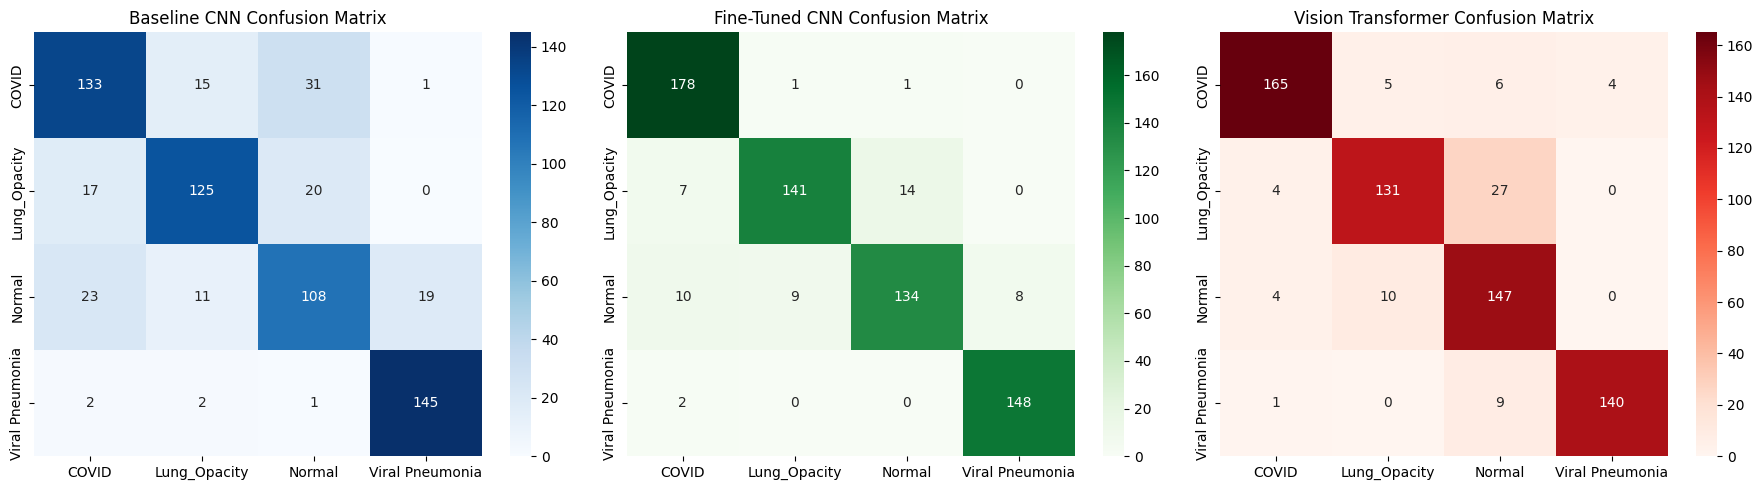

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

classes = ['COVID','Lung_Opacity','Normal','Viral Pneumonia']

cm_baseline = np.array([
[133,15,31,1],
[17,125,20,0],
[23,11,108,19],
[2,2,1,145]
])

cm_finetune = np.array([
[178,1,1,0],
[7,141,14,0],
[10,9,134,8],
[2,0,0,148]
])

cm_vit = np.array([
[165,5,6,4],
[4,131,27,0],
[4,10,147,0],
[1,0,9,140]
])

fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title("Baseline CNN Confusion Matrix")

sns.heatmap(cm_finetune, annot=True, fmt="d", cmap="Greens",
            xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title("Fine-Tuned CNN Confusion Matrix")

sns.heatmap(cm_vit, annot=True, fmt="d", cmap="Reds",
            xticklabels=classes, yticklabels=classes, ax=axes[2])
axes[2].set_title("Vision Transformer Confusion Matrix")

plt.tight_layout()
plt.show()

import seaborn and matplotlib for plotting and numpy fro numeric array

defines a list of 4 class names in order for confusion matrix

The Confusion mayrix TRUE vs PREDICTED for basline cnn as 4*4 numpy array as each row a true class, each column a predited class in order given by class.

same idea of confusion matrix for remaining models, fine tuned cnn and VIT

ceate a figure with 1 row and 3 columns of subplot side by side

draw heatmap of the baseline cnn confusion matrix using blue colour, with X and Y axis use class names

same for remaining model confusion matrixes with fine tuned CNN in green colour and fine tuned VIT with red colour.

Adjust the spacing dont overlap and display the figure.

# Model Comparison Chart

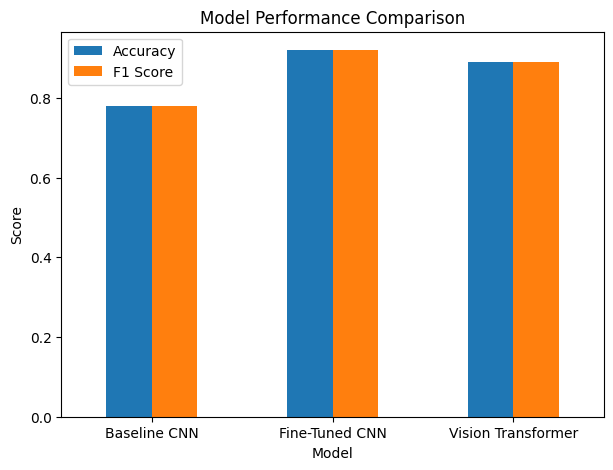

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
'Model':['Baseline CNN','Fine-Tuned CNN','Vision Transformer'],
'Accuracy':[0.78,0.92,0.89],
'F1 Score':[0.78,0.92,0.89]
})

results.set_index('Model').plot(kind='bar', figsize=(7,5))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend()
plt.show()

Imports pandas for tabular data and matplotlib for plotting.

Creates a small DataFrame called results with three rows (one per model).

Plots a bar chart:
X‑axis: model names.
Y‑axis: values of Accuracy and F1 Score (two bars per model).

Labels the y‑axis as “Score”.
Rotates x‑tick labels to 0 degrees so names are horizontal and Display the plot

## ROC Curve for ALL models

In [ ]:
## Calculating probabilities for all models

# collect probabilities for ROC curve

import torch.nn.functional as F

model1.eval()

all_labels = []
all_probs_baseline = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model1(images)

        probs = F.softmax(outputs, dim=1).cpu().numpy()

        all_probs_baseline.extend(probs)
        all_labels.extend(labels.numpy())


model1.eval() and torch.no_grad() ensure evalutaion mode and no gradient computation.

F.softmax converts the logits from model1 to probabilities over the 4 classes.

all_probs_baseline becomes list of prob vectors, one per test image

all_labels stores the true integer labels for the same images.


In [ ]:
model2.eval()

all_probs_finetune = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model2(images)

        probs = F.softmax(outputs, dim=1).cpu().numpy()

        all_probs_finetune.extend(probs)

Same idea as above, but for model2 (fine‑tuned ResNet).

Reuses all_labels from Cell 29 for the ground truth.

all_probs_finetune now holds probabilities from the fine‑tuned model.

In [ ]:
model3.eval()

all_probs_vit = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model3(images)

        probs = F.softmax(outputs, dim=1).cpu().numpy()

        all_probs_vit.extend(probs)

Again the same procedure for the Vision Transformer (model3).

all_probs_vit holds probabilities from ViT for each test image.

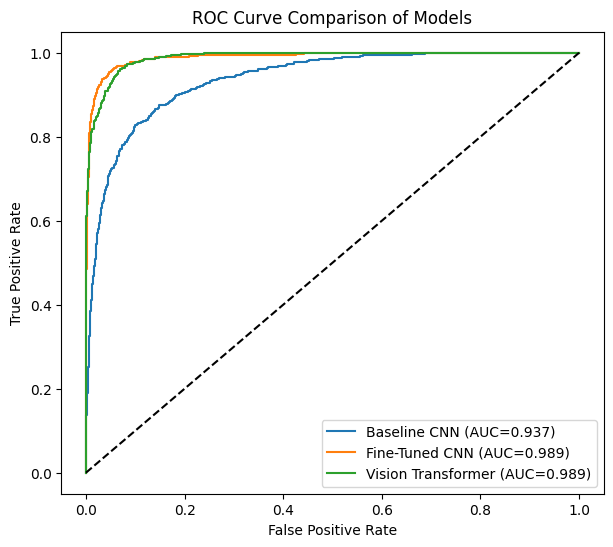

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# convert labels to binary format
y_true = np.array(all_labels)
y_bin = label_binarize(y_true, classes=[0,1,2,3])

# assume these probabilities were captured during evaluation
# if not, rerun evaluation capturing softmax outputs
y_score_baseline = np.array(all_probs_baseline)
y_score_finetune = np.array(all_probs_finetune)
y_score_vit = np.array(all_probs_vit)

plt.figure(figsize=(7,6))

for scores, name in [
    (y_score_baseline,"Baseline CNN"),
    (y_score_finetune,"Fine-Tuned CNN"),
    (y_score_vit,"Vision Transformer")
]:

    fpr, tpr, _ = roc_curve(y_bin.ravel(), scores.ravel())
    roc_auc = auc(fpr,tpr)

    plt.plot(fpr,tpr,label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()
plt.show()

## Per-Class ROC Curves

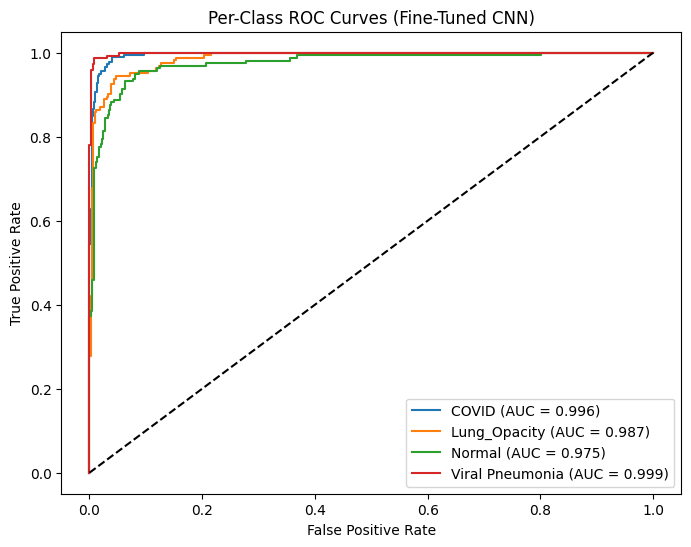

In [ ]:
# Per-class ROC Curves for Fine-Tuned CNN

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

classes = ['COVID','Lung_Opacity','Normal','Viral Pneumonia']

# convert labels to one-hot format
y_true_bin = label_binarize(all_labels, classes=[0,1,2,3])

y_score = np.array(all_probs_finetune)

plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-Class ROC Curves (Fine-Tuned CNN)")
plt.legend()

plt.show()

## Explainable AI (Grad - CAM)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


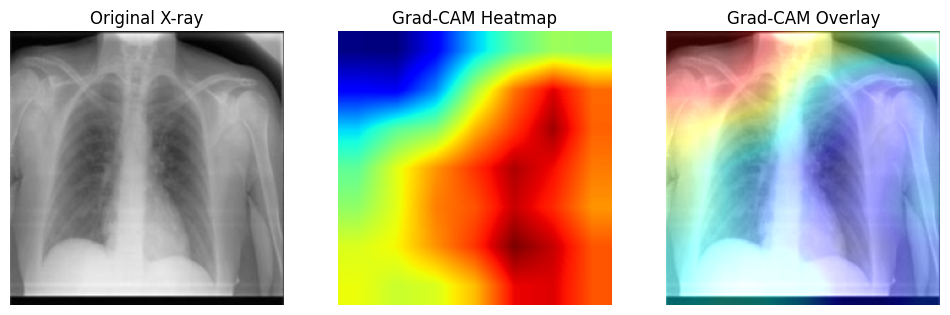

True label: 0
Predicted label: 0


In [ ]:
# Grad-CAM visualization for the Fine-Tuned CNN model

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

# set model to evaluation mode
model2.eval()

# get one batch from test loader
images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0).to(device)
label = labels[0].item()

# forward pass
output = model2(image)
pred_class = torch.argmax(output).item()

# get last convolution layer
target_layer = model2.layer4[-1]

# containers for gradients and activations
gradients = []
activations = []

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

def forward_hook(module, inp, out):
    activations.append(out)

# register hooks
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

# forward pass again for hooks
output = model2(image)
score = output[0, pred_class]

# backward pass
model2.zero_grad()
score.backward()

# get gradients and activations
grads = gradients[0].cpu().detach().numpy()[0]
acts = activations[0].cpu().detach().numpy()[0]

# compute weights
weights = np.mean(grads, axis=(1,2))

# generate Grad-CAM map
cam = np.zeros(acts.shape[1:], dtype=np.float32)

for i, w in enumerate(weights):
    cam += w * acts[i]

cam = np.maximum(cam, 0)
cam = cv2.resize(cam, (224,224))
cam = cam / cam.max()

# prepare original image
img = image.cpu().detach().numpy()[0].transpose(1,2,0)
img = (img - img.min()) / (img.max() - img.min())

# heatmap
heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
heatmap = heatmap / 255

# overlay
overlay = heatmap * 0.4 + img

# plot results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original X-ray")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cam, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.show()

print("True label:", label)
print("Predicted label:", pred_class)

## Grad-CAM for All Classes

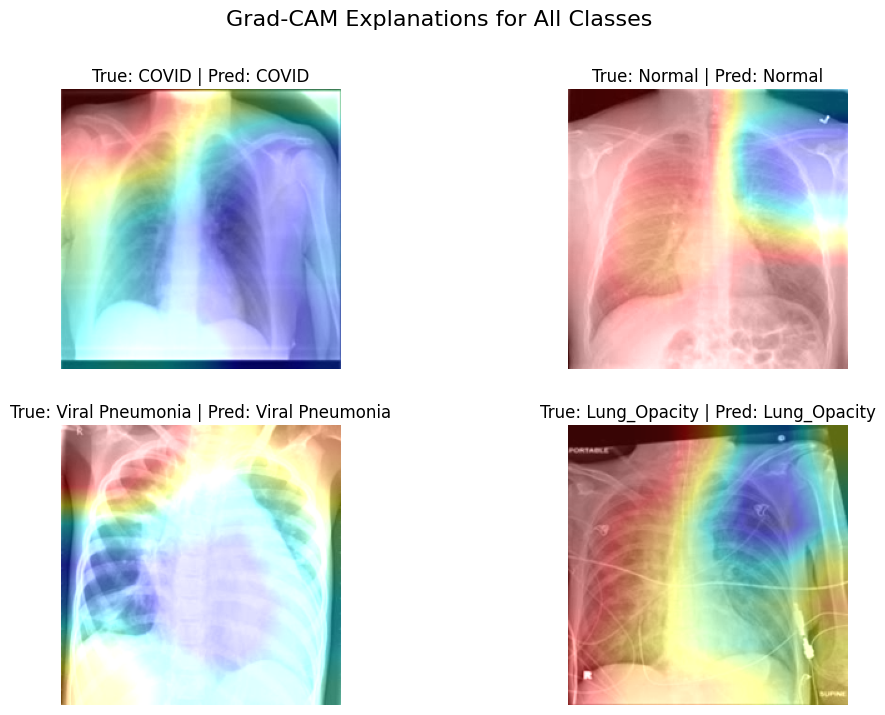

In [ ]:
# Grad-CAM visualisation for one sample from each class

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch.nn.functional as F

classes = ['COVID','Lung_Opacity','Normal','Viral Pneumonia']

model2.eval()

# function to generate gradcam
def generate_gradcam(model, image):

    gradients = []
    activations = []

    def forward_hook(module, inp, out):
        activations.append(out)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    target_layer = model.layer4[-1]

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_backward_hook(backward_hook)

    output = model(image)
    pred_class = torch.argmax(output)

    score = output[0, pred_class]

    model.zero_grad()
    score.backward()

    grads = gradients[0].cpu().detach().numpy()[0]
    acts = activations[0].cpu().detach().numpy()[0]

    weights = np.mean(grads, axis=(1,2))

    cam = np.zeros(acts.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam,0)
    cam = cv2.resize(cam,(224,224))
    cam = cam / cam.max()

    handle_f.remove()
    handle_b.remove()

    return cam, pred_class.item()

# get one image from each class
samples = {}

for images, labels in test_loader:
    for img, lbl in zip(images, labels):
        if lbl.item() not in samples:
            samples[lbl.item()] = img.unsqueeze(0)
        if len(samples) == 4:
            break
    if len(samples) == 4:
        break

plt.figure(figsize=(12,8))

for i,(label,img) in enumerate(samples.items()):

    img = img.to(device)

    cam, pred = generate_gradcam(model2,img)

    original = img.cpu().numpy()[0].transpose(1,2,0)
    original = (original - original.min())/(original.max()-original.min())

    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = heatmap/255

    overlay = heatmap*0.4 + original

    plt.subplot(2,2,i+1)
    plt.imshow(overlay)
    plt.title(f"True: {classes[label]} | Pred: {classes[pred]}")
    plt.axis("off")

plt.suptitle("Grad-CAM Explanations for All Classes", fontsize=16)
plt.show()